# Step1: ライブラリのインポートとデータ準備

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')
sns.set_style('white')

import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

In [16]:
BASE_DIR = '/kaggle/input/competitions/playground-series-s6e6'
TRAIN_DIR = BASE_DIR + '/train.csv'
TEST_DIR = BASE_DIR + '/test.csv'

train_raw = pd.read_csv(TRAIN_DIR)
test_raw = pd.read_csv(TEST_DIR)
train_df = train_raw.copy(deep=True)
test_df = test_raw.copy(deep=True)
data_cleaner = [train_df, test_df]

train_df.head(10)

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY
5,5,250.727869,31.756548,20.926469,19.693480,18.902361,19.247572,18.508241,0.076299,G/K,Blue_Cloud,STAR
6,6,0.752529,-2.936677,22.829195,22.686143,20.583886,19.781338,19.410491,0.575080,M,Red_Sequence,GALAXY
7,7,235.611325,39.626517,22.511467,21.480306,21.765645,21.508658,21.333476,2.159269,O/B,Blue_Cloud,QSO
8,8,355.359230,2.182312,20.396550,20.064767,19.892257,19.836272,19.860081,0.900087,A/F,Blue_Cloud,QSO
9,9,254.980080,38.743449,18.839137,17.997845,18.458894,18.229552,19.202247,0.114302,O/B,Blue_Cloud,STAR


## Step2: 特徴量理解

In [17]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577347 entries, 0 to 577346
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 577347 non-null  int64  
 1   alpha              577347 non-null  float64
 2   delta              577347 non-null  float64
 3   u                  577347 non-null  float64
 4   g                  577347 non-null  float64
 5   r                  577347 non-null  float64
 6   i                  577347 non-null  float64
 7   z                  577347 non-null  float64
 8   redshift           577347 non-null  float64
 9   spectral_type      577347 non-null  object 
 10  galaxy_population  577347 non-null  object 
 11  class              577347 non-null  object 
dtypes: float64(8), int64(1), object(3)
memory usage: 52.9+ MB


In [18]:
train_df.describe()

,id,alpha,delta,u,g,r,i,z,redshift
count,577347.00000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000
mean,288673.00000,181.616673,21.834654,22.441926,21.007273,19.962811,19.378911,19.041136,0.723135
std,166665.86727,96.242941,18.933570,2.018135,1.795426,1.648964,1.580059,1.584365,0.810070
min,0.00000,0.011684,-17.966988,-0.139225,13.535483,12.579407,11.962781,11.682803,-0.009970
25%,144336.50000,132.161499,2.474097,20.977090,19.865005,18.820671,18.306820,17.973192,0.181052
50%,288673.00000,188.681465,21.484412,22.570222,21.467820,20.431153,19.631642,19.188598,0.497525
75%,433009.50000,231.829693,36.988310,23.869103,22.292715,21.164096,20.608191,20.162111,0.881390
max,577346.00000,359.999810,79.158322,28.253263,27.620208,25.254499,27.910853,26.826867,7.010780


In [19]:
train_df.describe(include=['O'])

,spectral_type,galaxy_population,class
count,577347,577347,577347
unique,4,2,3
top,M,Red_Sequence,GALAXY
freq,303323,319565,377480


In [20]:
train_df['class'].value_counts()

class
GALAXY    377480
QSO       117143
STAR       82724
Name: count, dtype: int64

# Step3: 特徴量エンジニアリング

### 3.1 連続値をビニング処理

In [21]:
#for dataset in data_cleaner:
#    dataset['alpha'] = pd.qcut(dataset['alpha'], 5)

### 3.2 カテゴリ変数のダミー化

In [22]:
label = LabelEncoder()
for dataset in data_cleaner:
    dataset['spectral_Code'] = label.fit_transform(dataset['spectral_type'])
    dataset['galaxy_Code'] = label.fit_transform(dataset['galaxy_population'])
    print(dataset.head())

   id       alpha      delta          u          g          r          i  \
0   0  147.734256  16.959273  25.472123  21.895559  20.357926  19.257113   
1   1  127.988677  32.346716  20.778509  19.087062  17.587208  17.226067   
2   2  179.792648  35.344843  21.035203  21.079128  21.171840  20.582629   
3   3  225.818295  48.569421  23.305056  21.050736  19.017754  18.365658   
4   4  141.836135  19.342852  21.703158  19.471680  18.234449  17.899447   

           z  redshift spectral_type galaxy_population   class  spectral_Code  \
0  18.621057  0.408982             M      Red_Sequence  GALAXY              2   
1  16.786433  0.157976             M      Red_Sequence  GALAXY              2   
2  20.557366  2.823770           O/B        Blue_Cloud     QSO              3   
3  17.914952  0.536099             M      Red_Sequence  GALAXY              2   
4  17.616185  0.555761             M      Red_Sequence  GALAXY              2   

   galaxy_Code  
0            1  
1            1  
2    

### 3.3 データラベルの整理

In [33]:
# 目的変数
Target = ['class']

# オリジナルのx成分
data_x = ['alpha', 'delta', 'u', 'g', 'r',
          'i', 'z', 'redshift', 'spectral_type',
          'galaxy_population']

# 計算用のx成分
data_x_calc = ['alpha', 'delta', 'u', 'g', 'r',
              'i', 'z', 'redshift', 'spectral_Code',
              'galaxy_Code']
data_xy = Target + data_x
print('Original X Y: ', data_xy, '\n')

# ダミー変数化したx成分
data_dummy = pd.get_dummies(train_df[data_x], drop_first=True, dtype=int)
test_dummy = pd.get_dummies(test_df[data_x], drop_first=True, dtype=int)
data_x_dummy = data_dummy.columns.tolist()
data_xy_dummy = Target + data_x_dummy
print('Dummy X Y: ', data_xy_dummy, '\n')
data_dummy.head()

Original X Y:  ['class', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift', 'spectral_type', 'galaxy_population'] 

Dummy X Y:  ['class', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift', 'spectral_type_G/K', 'spectral_type_M', 'spectral_type_O/B', 'galaxy_population_Red_Sequence'] 



,alpha,delta,u,g,r,i,z,redshift,spectral_type_G/K,spectral_type_M,spectral_type_O/B,galaxy_population_Red_Sequence
0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,0,1,0,1
1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,0,1,0,1
2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,0,0,1,0
3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,0,1,0,1
4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,0,1,0,1


### 3.4 訓練データと検証データに分割

In [31]:
train_x, valid_x, train_y, valid_y = train_test_split(train_df[data_x_calc], train_df[Target], random_state=0)
train_x_dummy, valid_x_dummy, train_y_dummy, valid_y_dummy = train_test_split(data_dummy[data_x_dummy], train_df[Target], random_state=0)

print("Train_df Shape: {}".format(train_df.shape))
print("Train_x Shape: {}".format(train_x.shape))
print("Valid_x Shape: {}".format(valid_x.shape))

Train_df Shape: (577347, 14)
Train_x Shape: (433010, 10)
Valid_x Shape: (144337, 10)


## Step4: EDAと可視化

In [25]:
# ピボットテーブルでグルーピング
for x in data_x:
    if train_df[x].dtype != 'float64':
        print('class correlation by:', x)
        pivot_df = pd.crosstab(train_df[x], train_df['class'], margins=True, margins_name='合計')
        print(pivot_df)
        print('-'*10, '\n')

class correlation by: spectral_type
class          GALAXY     QSO   STAR      合計
spectral_type                               
A/F             24240   61514  36368  122122
G/K             61627   20921  25998  108546
M              288023    3889  11411  303323
O/B              3590   30819   8947   43356
合計             377480  117143  82724  577347
---------- 

class correlation by: galaxy_population
class              GALAXY     QSO   STAR      合計
galaxy_population                               
Blue_Cloud          88962  108274  60546  257782
Red_Sequence       288518    8869  22178  319565
合計                 377480  117143  82724  577347
---------- 



Text(0, 0.5, 'redshift')

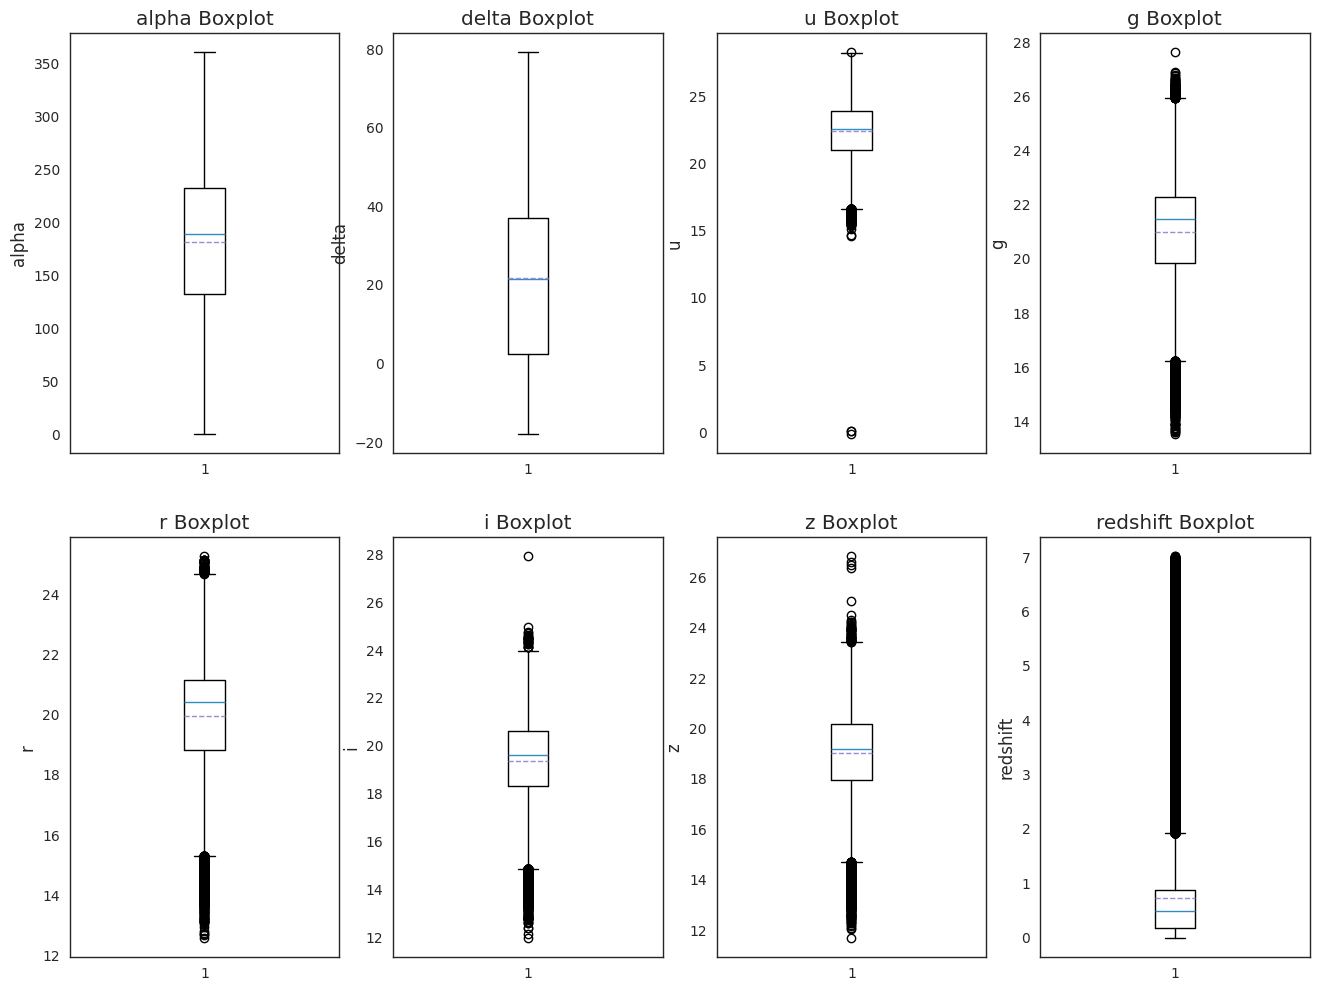

In [26]:
# 定量データ分布
plt.figure(figsize=[16, 12])

plt.subplot(241)
plt.boxplot(x=train_df['alpha'], showmeans=True, meanline=True)
plt.title('alpha Boxplot')
plt.ylabel('alpha')

plt.subplot(242)
plt.boxplot(x=train_df['delta'], showmeans=True, meanline=True)
plt.title('delta Boxplot')
plt.ylabel('delta')

plt.subplot(243)
plt.boxplot(x=train_df['u'], showmeans=True, meanline=True)
plt.title('u Boxplot')
plt.ylabel('u')

plt.subplot(244)
plt.boxplot(x=train_df['g'], showmeans=True, meanline=True)
plt.title('g Boxplot')
plt.ylabel('g')

plt.subplot(245)
plt.boxplot(x=train_df['r'], showmeans=True, meanline=True)
plt.title('r Boxplot')
plt.ylabel('r')

plt.subplot(246)
plt.boxplot(x=train_df['i'], showmeans=True, meanline=True)
plt.title('i Boxplot')
plt.ylabel('i')

plt.subplot(247)
plt.boxplot(x=train_df['z'], showmeans=True, meanline=True)
plt.title('z Boxplot')
plt.ylabel('z')

plt.subplot(248)
plt.boxplot(x=train_df['redshift'], showmeans=True, meanline=True)
plt.title('redshift Boxplot')
plt.ylabel('redshift')

<Axes: xlabel='redshift', ylabel='Count'>

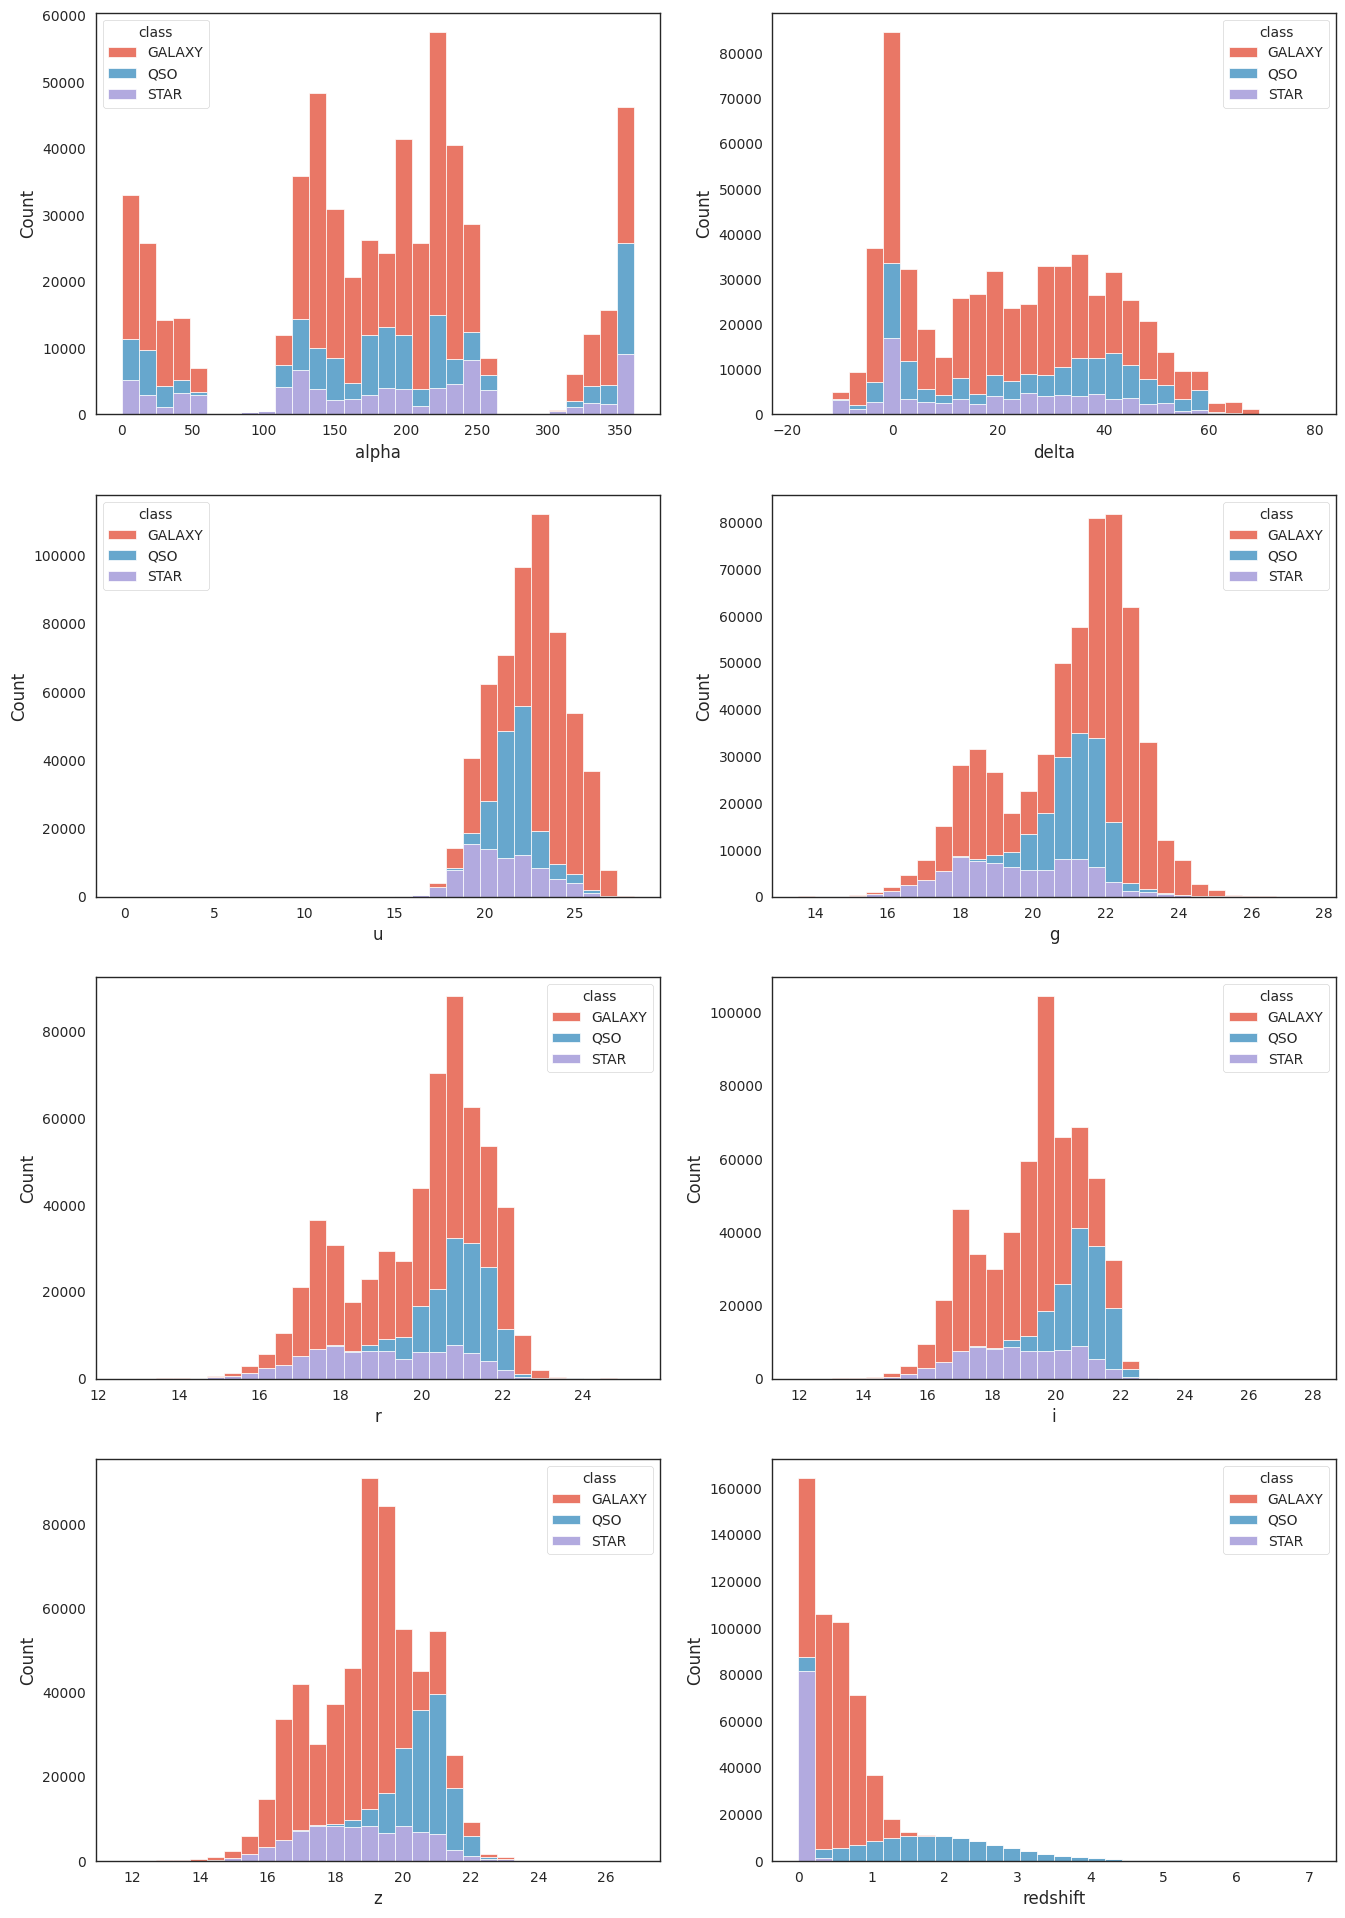

In [27]:
fig, saxis = plt.subplots(4, 2, figsize=(16, 24))

sns.histplot(data=train_df, x='alpha', hue='class',
             bins=30, multiple='stack', ax=saxis[0, 0])
sns.histplot(data=train_df, x='delta', hue='class',
            bins=30, multiple='stack', ax=saxis[0, 1])
sns.histplot(data=train_df, x='u', hue='class',
            bins=30, multiple='stack', ax=saxis[1, 0])
sns.histplot(data=train_df, x='g', hue='class',
            bins=30, multiple='stack', ax=saxis[1, 1])
sns.histplot(data=train_df, x='r', hue='class',
            bins=30, multiple='stack', ax=saxis[2, 0])
sns.histplot(data=train_df, x='i', hue='class',
            bins=30, multiple='stack', ax=saxis[2, 1])
sns.histplot(data=train_df, x='z', hue='class',
            bins=30, multiple='stack', ax=saxis[3, 0])
sns.histplot(data=train_df, x='redshift', hue='class',
            bins=30, multiple='stack', ax=saxis[3, 1])


## Step5: モデル作成と評価

In [34]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(data_dummy)

clf = LogisticRegression(multi_class='multinomial', solver='lbfgs', random_state=1)
clf.fit(x_scaled, train_df[Target])

LogisticRegression(multi_class='multinomial', random_state=1)

## Step6: 提出データ作成

In [37]:
test_scaled = scaler.fit_transform(test_dummy)
y_pred = clf.predict(test_scaled)

['GALAXY' 'GALAXY' 'GALAXY' ... 'GALAXY' 'QSO' 'GALAXY']


In [38]:
df_sub = pd.DataFrame(data=test_df[['id']])
df_sub['class'] = y_pred
df_sub

,id,class
0,577347,GALAXY
1,577348,GALAXY
2,577349,GALAXY
3,577350,STAR
4,577351,GALAXY
...,...,...
247430,824777,QSO
247431,824778,QSO
247432,824779,GALAXY
247433,824780,QSO


In [39]:
df_sub.to_csv('submission.csv', index=False)
print('Your submission was successfully saved!')

Your submission was successfully saved!
